# Exploratory Data Analysis



In [1]:
import glob, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

RAW = 'data/raw'
READINGS_DIR = f'{RAW}/meter_readings'
EVENTS_DIR = f'{RAW}/meter_events'
REF_DIR = f'{RAW}/reference'

def load_many(folder, pattern):
    # Load and concat all CSVs matching a glob, tagging each row with its source file.
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    frames, per_file = [], []
    for f in files:
        d = pd.read_csv(f, dtype=str, keep_default_na=False)
        d['source_file'] = os.path.basename(f)
        per_file.append((os.path.basename(f), len(d)))
        frames.append(d)
    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return df, per_file

def load_ref(name):
    return pd.read_csv(os.path.join(REF_DIR, name), dtype=str, keep_default_na=False)

readings, readings_per_file = load_many(READINGS_DIR, 'meter_readings_*.csv')
events, events_per_file = load_many(EVENTS_DIR, 'meter_events_*.csv')
meters = load_ref('meters.csv')
buildings = load_ref('buildings.csv')
regions = load_ref('regions.csv')
tariffs = load_ref('tariffs.csv')

tables = {
    'readings': readings,
    'events': events,
    'meters': meters,
    'buildings': buildings,
    'regions': regions,
    'tariffs': tariffs,
}

print('readings files:', len(readings_per_file))
for name, n in readings_per_file:
    print(f'{name}: {n:,} rows')
print('events files :', len(events_per_file))
for name, n in events_per_file:
    print(f'{name}: {n:,} rows')

readings files: 7
meter_readings_2026_01_01.csv: 47,661 rows
meter_readings_2026_01_02.csv: 47,880 rows
meter_readings_2026_01_03.csv: 47,882 rows
meter_readings_2026_01_04.csv: 47,883 rows
meter_readings_2026_01_05.csv: 47,890 rows
meter_readings_2026_01_06.csv: 47,865 rows
meter_readings_2026_01_07.csv: 47,869 rows
events files : 7
meter_events_2026_01_01.csv: 250 rows
meter_events_2026_01_02.csv: 250 rows
meter_events_2026_01_03.csv: 250 rows
meter_events_2026_01_04.csv: 250 rows
meter_events_2026_01_05.csv: 250 rows
meter_events_2026_01_06.csv: 250 rows
meter_events_2026_01_07.csv: 250 rows


## 1. Table overview — row & column counts

In [2]:
overview = pd.DataFrame(
    [{'table': name,
      'rows': len(df),
      'columns': sum(c != 'source_file' for c in df.columns),
      'column_names': ', '.join(c for c in df.columns if c != 'source_file')}
      for name, df in tables.items()]
).set_index('table')
display(overview)

,rows,columns,column_names
table,,,
readings,334930,9,"reading_id, meter_id, reading_timestamp, energ..."
events,1750,6,"event_id, meter_id, event_timestamp, event_typ..."
meters,500,6,"meter_id, building_id, meter_type, installatio..."
buildings,200,5,"building_id, region_id, building_type, floor_a..."
regions,10,4,"region_id, region_name, country, climate_zone"
tariffs,40,7,"tariff_id, region_id, valid_from, valid_to, ta..."


## 2. Per-table profile

For every column: how many non-blank vs blank cells, how many distinct values, and the
three most common values (with counts). source_file is the lineage tag added at load.

In [3]:
def profile(df):
    rows = []
    for c in df.columns:
        s = df[c].astype(str)
        blank = s.str.strip() == ''
        nonblank = s[~blank]
        top = nonblank.value_counts().head(3)
        rows.append({
            'non_blank': int((~blank).sum()),
            'blank': int(blank.sum()),
            'blank_%': round(100 * blank.mean(), 2),
            'distinct': int(nonblank.nunique()),
            'top_values': ', '.join(f'{v} ({n})' for v, n in top.items()),
        })
    return pd.DataFrame(rows, index=df.columns).rename_axis('column')

for name, df in tables.items():
    print(f'\n===== {name} ({len(df):,} rows) =====')
    display(profile(df))


===== readings (334,930 rows) =====


,non_blank,blank,blank_%,distinct,top_values
column,,,,,
reading_id,334930,0,0.0,334930,"R0000000001 (1), R0000000002 (1), R0000000003 (1)"
meter_id,334265,665,0.2,997,"131 (681), 267 (679), 175 (677)"
reading_timestamp,334930,0,0.0,673,"2026-01-02 14:00:00 (507), 2026-01-04 09:00:00..."
energy_kwh,334930,0,0.0,35410,"0.02 (279), 0.0298 (95), 0.0322 (89)"
voltage,334930,0,0.0,2556,"230.24 (416), 229.32 (414), 229.86 (414)"
current,334930,0,0.0,7868,"0.56 (411), 0.59 (409), 0.55 (400)"
power_factor,334930,0,0.0,191,"1.0 (8018), 0.942 (4586), 0.94 (4506)"
reading_type,334930,0,0.0,4,"actual (290515), estimated (43659), corrected ..."
source_system,334930,0,0.0,3,"meter_gateway (290515), legacy_import (43659),..."



===== events (1,750 rows) =====


,non_blank,blank,blank_%,distinct,top_values
column,,,,,
event_id,1750,0,0.0,1750,"E000000001 (1), E000000002 (1), E000000003 (1)"
meter_id,1750,0,0.0,511,"421 (9), 183 (8), 440 (8)"
event_timestamp,1750,0,0.0,1578,"2026-99-99 99:99:99 (21), 2026-01-04 12:39:00 ..."
event_type,1750,0,0.0,6,"connection_lost (447), firmware_update (341), ..."
severity,1750,0,0.0,3,"high (818), medium (591), low (341)"
description,1750,0,0.0,6,"connection lost detected (447), firmware updat..."
source_file,1750,0,0.0,7,"meter_events_2026_01_01.csv (250), meter_event..."



===== meters (500 rows) =====


...

,non_blank,blank,blank_%,distinct,top_values
column,,,,,
building_id,200,0,0.0,200,"1 (1), 2 (1), 3 (1)"
region_id,200,0,0.0,10,"5 (26), 10 (26), 7 (21)"
building_type,200,0,0.0,6,"residential (78), office (34), school (25)"
floor_area_sqm,200,0,0.0,179,"35 (4), 107 (3), 65 (3)"
customer_type,200,0,0.0,4,"household (78), commercial (57), public (47)"



===== regions (10 rows) =====


,non_blank,blank,blank_%,distinct,top_values
column,,,,,
region_id,10,0,0.0,10,"1 (1), 2 (1), 3 (1)"
region_name,10,0,0.0,10,"London North (1), London South (1), Manchester..."
country,10,0,0.0,4,"UK (4), DE (2), FR (2)"
climate_zone,10,0,0.0,2,"temperate (8), warm (2)"



===== tariffs (40 rows) =====


,non_blank,blank,blank_%,distinct,top_values
column,,,,,
tariff_id,40,0,0.0,40,"1 (1), 2 (1), 3 (1)"
region_id,40,0,0.0,10,"1 (4), 2 (4), 3 (4)"
valid_from,40,0,0.0,1,2025-07-05 (40)
valid_to,40,0,0.0,1,2027-01-01 (40)
tariff_type,40,0,0.0,4,"standard (10), peak (10), off_peak (10)"
price_per_kwh,40,0,0.0,40,"0.241 (1), 0.3243 (1), 0.1689 (1)"
peak_period_flag,40,0,0.0,2,"False (30), True (10)"


## 3. Missing / blank values

In [4]:
miss = []
for name, df in tables.items():
    for c in df.columns:
        if c == 'source_file':
            continue
        b = int((df[c].astype(str).str.strip() == '').sum())
        if b:
            miss.append({'table': name, 'column': c,
                         'blank': b, 'blank_%': round(100 * b / len(df), 2)})

missing_df = pd.DataFrame(miss)
if len(missing_df):
    display(missing_df.sort_values('blank', ascending=False).reset_index(drop=True))
else:
    print('No blank / empty values found in any table.')

,table,column,blank,blank_%
0,readings,meter_id,665,0.2


## 4. Numeric column checks

In [5]:
numeric_cols = {
    'readings': ['energy_kwh', 'voltage', 'current', 'power_factor'],
    'meters': ['expected_reading_frequency_minutes'],
    'buildings': ['floor_area_sqm'],
    'tariffs': ['price_per_kwh'],
}
for tname, cols in numeric_cols.items():
    df = tables[tname]
    out = {}
    for c in cols:
        if c not in df.columns:
            continue
        raw = df[c].astype(str).str.strip()
        num = pd.to_numeric(raw, errors='coerce')
        out[c] = {
            'non_numeric': int(((raw != '') & num.isna()).sum()),
            'min': num.min(),
            'max': num.max(),
            'mean': round(num.mean(), 4) if num.notna().any() else np.nan,
            'negatives': int((num < 0).sum()),
        }
    print(f'\n===== {tname} =====')
    display(pd.DataFrame(out).T)


===== readings =====


,non_numeric,min,max,mean,negatives
energy_kwh,0.0,-5.9988,249.3201,0.9885,498.0
voltage,0.0,75.0000,460.0000,230.0197,0.0
current,0.0,0.2900,91.3100,14.2335,0.0
power_factor,0.0,-0.2000,1.4000,0.9396,82.0



===== meters =====


,non_numeric,min,max,mean,negatives
expected_reading_frequency_minutes,0.0,15.0,60.0,16.71,0.0



===== buildings =====


,non_numeric,min,max,mean,negatives
floor_area_sqm,0.0,35.0,11591.0,1375.41,0.0



===== tariffs =====


,non_numeric,min,max,mean,negatives
price_per_kwh,0.0,0.1689,0.4063,0.297,0.0


## 5. Timestamp checks

In [6]:
ts_cols = {'readings': 'reading_timestamp', 'events': 'event_timestamp'}
for tname, c in ts_cols.items():
    df = tables[tname]
    if c not in df.columns or len(df) == 0:
        continue
    parsed = pd.to_datetime(df[c], errors='coerce')
    print(f'{tname}.{c}: {int(parsed.isna().sum())} unparseable | '
            f'range {parsed.min()} -> {parsed.max()}')

if len(readings):
    per_day = pd.to_datetime(readings['reading_timestamp'], errors='coerce').dt.date
    print('\nreadings per day:')
    display(per_day.value_counts().sort_index().rename('rows').to_frame())

readings.reading_timestamp: 329 unparseable | range 2026-01-01 00:00:00 -> 2026-01-07 23:45:00
events.event_timestamp: 21 unparseable | range 2026-01-01 00:07:00 -> 2026-01-07 23:58:00

readings per day:


,rows
reading_timestamp,
2026-01-01,48000
2026-01-02,47898
2026-01-03,47848
2026-01-04,47793
2026-01-05,47732
2026-01-06,47674
2026-01-07,47656


## 6. Categorical value distributions

In [7]:
cat_cols = {
    'readings': ['reading_type', 'source_system'],
    'events': ['event_type', 'severity'],
    'meters': ['meter_type', 'status'],
    'buildings': ['building_type', 'customer_type'],
    'regions': ['country', 'climate_zone'],
    'tariffs': ['tariff_type', 'peak_period_flag'],
}
for tname, cols in cat_cols.items():
    df = tables[tname]
    for c in cols:
        if c in df.columns:
            print(f'\n--- {tname}.{c} ---')
            print(df[c].value_counts(dropna=False).to_string())


--- readings.reading_type ---
reading_type
actual             290515
estimated           43659
corrected             427
manual_estimate       329

--- readings.source_system ---
source_system
meter_gateway        290515
legacy_import         43659
manual_correction       756

--- events.event_type ---
event_type
connection_lost    447
firmware_update    341
low_voltage        330
meter_reset        261
high_voltage       232
tamper_alert       139

--- events.severity ---
severity
high      818
medium    591
low       341

--- meters.meter_type ---
meter_type
electricity_main        324
electricity_submeter    120
solar_generation         56

--- meters.status ---
status
active         427
inactive        44
maintenance     29

--- buildings.building_type ---
building_type
residential    78
office         34
school         25
retail         23
hospital       22
factory        18

--- buildings.customer_type ---
customer_type
household     78
commercial    57
public        47
industri

## 7. Primary-key uniqueness

In [8]:
pks = {
    'readings': 'reading_id',
    'events': 'event_id',
    'meters': 'meter_id',
    'buildings': 'building_id',
    'regions': 'region_id',
    'tariffs': 'tariff_id',
}
for tname, pk in pks.items():
    df = tables[tname]
    if pk not in df.columns:
        continue
    dups = int(df[pk].duplicated().sum())
    flag = 'OK' if dups == 0 else 'DUPLICATES'
    print(f'{tname:10s} {pk:12s}: {df[pk].nunique():,} unique of {len(df):,}  '
            f'-> {dups} duplicate(s)  [{flag}]')

readings   reading_id  : 334,930 unique of 334,930  -> 0 duplicate(s)  [OK]
events     event_id    : 1,750 unique of 1,750  -> 0 duplicate(s)  [OK]
meters     meter_id    : 500 unique of 500  -> 0 duplicate(s)  [OK]
buildings  building_id : 200 unique of 200  -> 0 duplicate(s)  [OK]
regions    region_id   : 10 unique of 10  -> 0 duplicate(s)  [OK]
tariffs    tariff_id   : 40 unique of 40  -> 0 duplicate(s)  [OK]


## 8. Referential integrity (foreign keys)

An *orphan* is a child key with no matching parent row. These are the joins the
silver/gold layers will rely on, so orphans here predict join losses downstream.

In [9]:
def fk_check(child, child_col, parent, parent_col):
    c = set(tables[child][child_col].astype(str).str.strip()) - {''}
    p = set(tables[parent][parent_col].astype(str).str.strip()) - {''}
    orphans = sorted(c - p)
    eg = f'  e.g. {orphans[:5]}' if orphans else ''
    print(f'{child}.{child_col} -> {parent}.{parent_col}: {len(orphans)} orphan key(s){eg}')

fk_check('readings','meter_id','meters','meter_id')
fk_check('events','meter_id','meters', 'meter_id')
fk_check('meters','building_id','buildings','building_id')
fk_check('buildings','region_id','regions','region_id')
fk_check('tariffs','region_id','regions','region_id')

readings.meter_id -> meters.meter_id: 497 orphan key(s)  e.g. ['UNK_20260101_000', 'UNK_20260101_001', 'UNK_20260101_002', 'UNK_20260101_003', 'UNK_20260101_004']
events.meter_id -> meters.meter_id: 28 orphan key(s)  e.g. ['UNK_EVT_20260101_00', 'UNK_EVT_20260101_03', 'UNK_EVT_20260101_06', 'UNK_EVT_20260101_09', 'UNK_EVT_20260102_00']
meters.building_id -> buildings.building_id: 0 orphan key(s)
buildings.region_id -> regions.region_id: 0 orphan key(s)
tariffs.region_id -> regions.region_id: 0 orphan key(s)


## 9. Quick visualisations

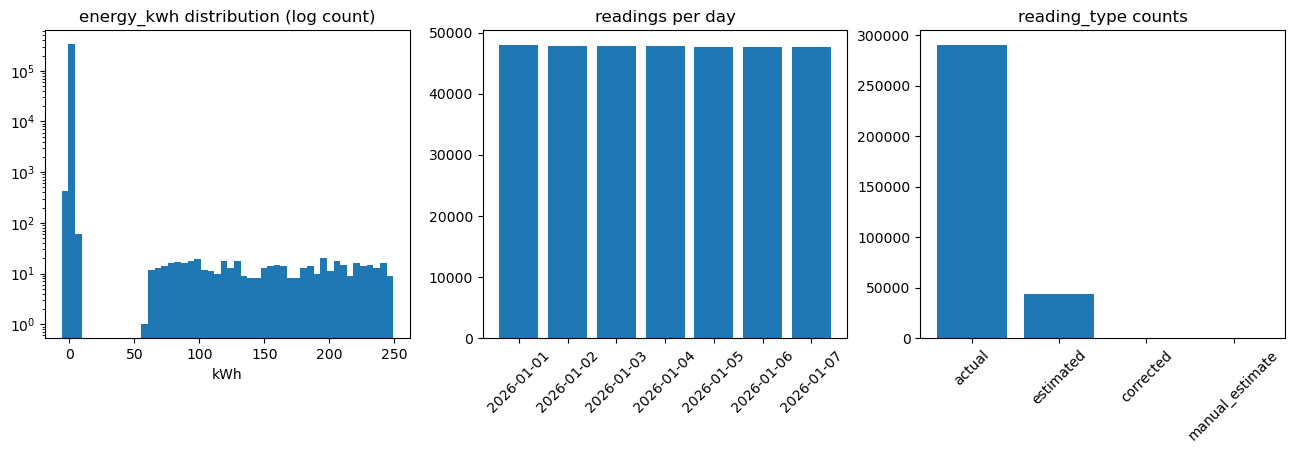

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

energy = pd.to_numeric(readings['energy_kwh'], errors='coerce').dropna()
axes[0].hist(energy, bins=50)
axes[0].set_yscale('log')
axes[0].set_title('energy_kwh distribution (log count)')
axes[0].set_xlabel('kWh')

per_day = pd.to_datetime(readings['reading_timestamp'], errors='coerce').dt.date.value_counts().sort_index()
axes[1].bar([str(d) for d in per_day.index], per_day.values)
axes[1].set_title('readings per day')
axes[1].tick_params(axis='x', rotation=45)

rt = readings['reading_type'].value_counts()
axes[2].bar(rt.index.astype(str), rt.values)
axes[2].set_title('reading_type counts')
axes[2].tick_params(axis='x', rotation=45)

plt.show()

## 10. Targeted data-quality deep dives

Each issue flagged above, quantified with examples so it can be documented and then
handled in the silver layer (reject / quarantine / repair).

### Blank meter IDs

### Unparseable timestamps

In [11]:
for tname, c in [('readings', 'reading_timestamp'), ('events', 'event_timestamp')]:
    df = tables[tname]
    parsed = pd.to_datetime(df[c], errors='coerce')
    bad = df.loc[parsed.isna(), c]
    print(f'{tname}.{c}: {len(bad):,} unparseable')
    display(bad.value_counts().head())

readings.reading_timestamp: 329 unparseable


reading_timestamp
2026-99-99 25:61:00    329
Name: count, dtype: int64

events.event_timestamp: 21 unparseable


event_timestamp
2026-99-99 99:99:99    21
Name: count, dtype: int64

### Negative & out-of-range numeric values


In [12]:
e = pd.to_numeric(readings['energy_kwh'], errors='coerce')
pf = pd.to_numeric(readings['power_factor'], errors='coerce')
v = pd.to_numeric(readings['voltage'], errors='coerce')

checks = {
    'energy_kwh < 0': int((e < 0).sum()),
    'power_factor < 0 or > 1': int(((pf < 0) | (pf > 1)).sum()),
    'voltage outside 207-253 V': int(((v < 207) | (v > 253)).sum()),
}
for k, n in checks.items():
    print(f'{k:28s}: {n:,}')


print('sample rows with negative energy_kwh:')
display(readings[e < 0][['reading_id', 'meter_id', 'reading_timestamp', 'energy_kwh', 'reading_type']].head())

energy_kwh < 0              : 498
power_factor < 0 or > 1     : 232
voltage outside 207-253 V   : 233
sample rows with negative energy_kwh:


,reading_id,meter_id,reading_timestamp,energy_kwh,reading_type
2334,R0000002335,25,2026-01-01 15:30:00,-2.2358,actual
3626,R0000003627,39,2026-01-01 05:00:00,-0.4962,actual
3806,R0000003807,41,2026-01-01 02:30:00,-2.4829,actual
4499,R0000004500,48,2026-01-01 09:15:00,-4.1568,actual
4553,R0000004554,48,2026-01-01 23:00:00,-5.5907,actual


### kWh spikes & outliers (better view)

A plain histogram is one bar because almost every value sits near zero with a long, sparse
tail. Log-count, a zoomed 1st-99th-percentile view, and a boxplot make the spikes visible.

,energy_kwh
count,334930.000000
mean,0.988497
std,6.312967
min,-5.998800
50%,0.401000
90%,2.326100
95%,2.681855
99%,3.634771
99.9%,117.525853
max,249.320100


top 10 largest energy_kwh:


104604    249.3201
182744    249.1500
204585    248.0838
247994    247.9220
186442    247.7414
317288    247.0059
231027    246.6533
107024    246.1371
2871      245.2768
82473     244.1648


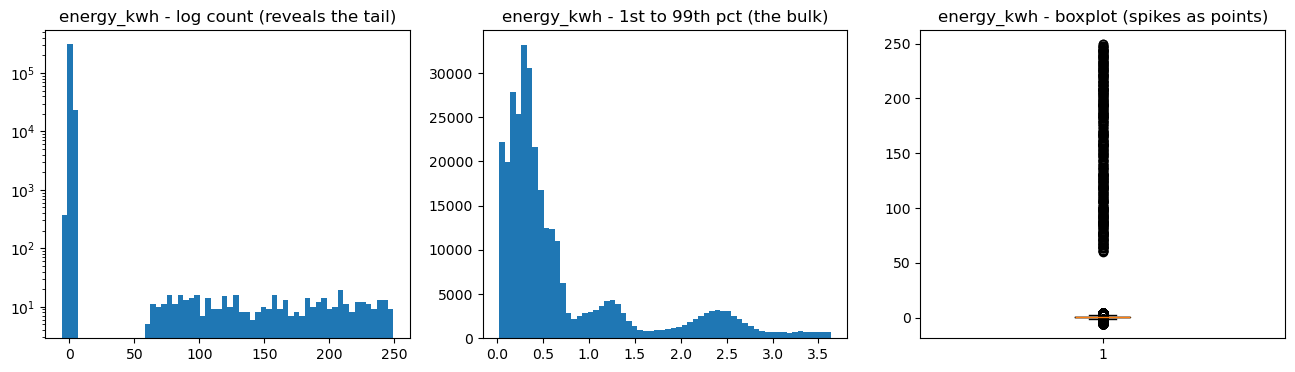

In [13]:
e = pd.to_numeric(readings['energy_kwh'], errors='coerce').dropna()
display(e.describe(percentiles=[.5, .9, .95, .99, .999]).to_frame('energy_kwh'))
print('top 10 largest energy_kwh:')
print(e.nlargest(10).to_string())

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(e, bins=60)
ax[0].set_yscale('log')
ax[0].set_title('energy_kwh - log count (reveals the tail)')

lo, hi = e.quantile(0.01), e.quantile(0.99)
ax[1].hist(e[(e >= lo) & (e <= hi)], bins=60)
ax[1].set_title('energy_kwh - 1st to 99th pct (the bulk)')

ax[2].boxplot(e, vert=True)
ax[2].set_title('energy_kwh - boxplot (spikes as points)')
plt.show()

### reading_type vs source_system

Testing the hypothesis that corrected and manual_estimate both originate from manual_correction.

In [14]:
ct = pd.crosstab(readings['reading_type'], readings['source_system'], margins=True)
display(ct)

source_system,legacy_import,manual_correction,meter_gateway,All
reading_type,,,,
actual,0,0,290515,290515
corrected,0,427,0,427
estimated,43659,0,0,43659
manual_estimate,0,329,0,329
All,43659,756,290515,334930


### Meter status vs readings

How many readings arrive from non-active meters (NaN = meter_id blank/unknown).

In [15]:
print('meters by status:')
print(meters['status'].value_counts().to_string())

status_map = meters.set_index('meter_id')['status']
read_status = readings['meter_id'].map(status_map)

print('readings by source meter status:')
print(read_status.value_counts(dropna=False).to_string())

meters by status:
status
active         427
inactive        44
maintenance     29
readings by source meter status:
meter_id
active         285700
inactive        28851
maintenance     19217
NaN              1162


### Reading frequency vs expectation

Observed median interval per meter compared with expected_reading_frequency_minutes.

In [16]:
r = readings[['meter_id', 'reading_timestamp']].copy()
r['ts'] = pd.to_datetime(r['reading_timestamp'], errors='coerce')
r = r.dropna(subset=['ts']).sort_values(['meter_id', 'ts'])
r['gap_min'] = r.groupby('meter_id')['ts'].diff().dt.total_seconds() / 60
observed = r.groupby('meter_id')['gap_min'].median()

expected = pd.to_numeric(meters.set_index('meter_id')['expected_reading_frequency_minutes'], errors='coerce')
print('expected frequency (minutes):')
print(expected.value_counts().sort_index().to_string())

cmp = pd.DataFrame({'expected_min': expected, 'observed_median_min': observed}).dropna()
mismatch = cmp[cmp['expected_min'] != cmp['observed_median_min']]
print(f'{len(mismatch)} of {len(cmp)} meters: observed median interval != expected')
display(cmp.head(10))

expected frequency (minutes):
expected_reading_frequency_minutes
15    463
30     27
60     10
37 of 500 meters: observed median interval != expected


,expected_min,observed_median_min
meter_id,,
1,15.0,15.0
10,15.0,15.0
100,15.0,15.0
101,15.0,15.0
102,30.0,15.0
103,15.0,15.0
104,15.0,15.0
105,15.0,15.0
106,15.0,15.0


### Duplicate rows


In [17]:
sub = readings[readings['meter_id'].astype(str).str.strip() != '']
dup_key = sub.duplicated(subset=['meter_id', 'reading_timestamp'], keep=False)
print(f'readings sharing (meter_id, reading_timestamp): {int(dup_key.sum()):,} rows')
display(sub[dup_key].sort_values(['meter_id', 'reading_timestamp'])
    [['reading_id', 'meter_id', 'reading_timestamp', 'energy_kwh', 'reading_type', 'source_system']]
    .head(10)
)
print('fully identical rows (ignoring source_file):',
        int(readings.drop(columns=['source_file']).duplicated().sum()))

readings sharing (meter_id, reading_timestamp): 4,767 rows


,reading_id,meter_id,reading_timestamp,energy_kwh,reading_type,source_system
24,R0000000025,1,2026-01-01 06:15:00,0.2652,actual,meter_gateway
239104,R0000239105,1,2026-01-01 06:15:00,0.2652,actual,meter_gateway
46,R0000000047,1,2026-01-01 12:00:00,0.7932,actual,meter_gateway
95508,R0000095509,1,2026-01-01 12:00:00,0.9034,corrected,manual_correction
55,R0000000056,1,2026-01-01 14:15:00,1.1177,estimated,legacy_import
47654,R0000047655,1,2026-01-01 14:15:00,1.1177,estimated,legacy_import
82,R0000000083,1,2026-01-01 21:00:00,0.6638,actual,meter_gateway
334854,R0000334855,1,2026-01-01 21:00:00,0.6638,actual,meter_gateway
143429,R0000143430,1,2026-01-04 01:30:00,0.3667,actual,meter_gateway
190966,R0000190967,1,2026-01-04 01:30:00,0.3667,actual,meter_gateway


fully identical rows (ignoring source_file): 0


### Late-arriving rows



In [18]:
def file_date(fn):
    parts = fn.replace('.csv', '').split('_')[-3:]
    return pd.Timestamp('-'.join(parts))

fdate = readings['source_file'].map(file_date)
rdate = pd.to_datetime(readings['reading_timestamp'], errors='coerce').dt.normalize()
offset_days = (rdate - fdate).dt.days

print('late-arriving (reading date < file date):', int((offset_days < 0).sum()))
print('same day :', int((offset_days == 0).sum()))
print('dated after file (future) :', int((offset_days > 0).sum()))
print('unparseable timestamp :', int(offset_days.isna().sum()))
print()
print('offset distribution (days, reading_date - file_date):')
display(offset_days.value_counts(dropna=False).sort_index().rename('rows').to_frame())

late-arriving (reading date < file date): 996
same day : 333605
dated after file (future) : 0
unparseable timestamp : 329

offset distribution (days, reading_date - file_date):


,rows
-6.0,27
-5.0,59
-4.0,92
-3.0,149
-2.0,257
-1.0,412
0.0,333605
NaN,329
